# 1.3 FK FFT Backend Benchmark

The FK standalone module (`fk.engine`, `fk.source`) now routes FFT calls through
`fk.fft_backend`, which uses **`scipy.fft` with `workers=-1`** when SciPy is
available and falls back to `numpy.fft` otherwise.

This notebook isolates the **inverse FFT step** that converts frequency-domain
displacement spectra `ux_spec`, `uz_spec` of shape `(nrcv, nfreq)` back to time,
and compares wall-clock time for:

| Backend | Call |
|---------|------|
| NumPy | `numpy.fft.irfft(..., axis=1)` |
| SciPy | `scipy.fft.irfft(..., axis=1, workers=-1)` |

## Experiment goals

1. Measure how IFFT wall time **scales with the number of receivers** `nrcv` at a
   fixed time length `nt` (FDFK default `nt = 4501`).
2. Measure how IFFT wall time **scales with `nt`** at a fixed receiver count.
3. Report the **speedup ratio** SciPy/NumPy as a function of problem size.

Each point is the **median** of several timed runs after warm-up.  The benchmark
times only the pair of `irfft` calls (ux + uz), matching `fk.engine`.

## 1. Setup

In [ ]:
import sys, os, time, gc
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.insert(0, os.path.abspath(".."))

import scipy
from scipy.fft import irfft as scipy_irfft
from fk.fft_backend import _HAS_SCIPY_FFT, irfft as fk_irfft

print(f"NumPy  {np.__version__}")
print(f"SciPy  {scipy.__version__}")
print(f"CPU cores: {os.cpu_count()}")
print(f"FK fft_backend uses SciPy: {_HAS_SCIPY_FFT}")

NumPy  1.26.4
SciPy  1.15.2
CPU cores: 12
FK fft_backend uses SciPy: True


## 2. Benchmark helpers

In [ ]:
def bench_pair_irfft(fn, spec, nt, n_warmup=2, n_runs=8):
    """Time two irfft calls (ux + uz) on the same spectrum array."""
    for _ in range(n_warmup):
        fn(spec, n=nt, axis=1)
        fn(spec, n=nt, axis=1)
    times = []
    for _ in range(n_runs):
        gc.collect()
        t0 = time.perf_counter()
        fn(spec, n=nt, axis=1)
        fn(spec, n=nt, axis=1)
        times.append(time.perf_counter() - t0)
    return np.median(times), np.array(times)


def make_spec(nrcv, nt, rng):
    nfreq = nt // 2 + 1
    spec = rng.standard_normal((nrcv, nfreq)) + 1j * rng.standard_normal((nrcv, nfreq))
    spec[:, 0] = 0.0  # zero DC, as in fk.engine
    return spec


numpy_irfft = np.fft.irfft
scipy_irfft_mt = lambda x, n, axis: scipy_irfft(x, n=n, axis=axis, workers=-1)

print("Helpers ready.")

Helpers ready.


## 3. Scaling with receiver count `nrcv`

Fixed `nt = 4501` (FDFK hybrid default).  Receiver counts span the range from a
single station to a dense profile.

In [ ]:
NT_DEFAULT = 4501
N_RCV_VALUES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
rng = np.random.default_rng(42)

times_numpy_rcv = []
times_scipy_rcv = []
times_fk_rcv = []

for nrcv in N_RCV_VALUES:
    spec = make_spec(nrcv, NT_DEFAULT, rng)
    t_np, _ = bench_pair_irfft(numpy_irfft, spec, NT_DEFAULT)
    t_sp, _ = bench_pair_irfft(scipy_irfft_mt, spec, NT_DEFAULT)
    t_fk, _ = bench_pair_irfft(fk_irfft, spec, NT_DEFAULT)
    times_numpy_rcv.append(t_np)
    times_scipy_rcv.append(t_sp)
    times_fk_rcv.append(t_fk)
    print(f"nrcv={nrcv:4d}  numpy={t_np*1e3:7.2f} ms  scipy={t_sp*1e3:7.2f} ms  fk_backend={t_fk*1e3:7.2f} ms  speedup={t_np/t_sp:5.2f}x")

times_numpy_rcv = np.array(times_numpy_rcv)
times_scipy_rcv = np.array(times_scipy_rcv)
times_fk_rcv = np.array(times_fk_rcv)
speedup_rcv = times_numpy_rcv / times_scipy_rcv

nrcv=   1  numpy=   0.44 ms  scipy=   0.28 ms  fk_backend=   0.26 ms  speedup= 1.59x


nrcv=   2  numpy=   0.59 ms  scipy=   0.36 ms  fk_backend=   0.36 ms  speedup= 1.65x


nrcv=   4  numpy=   0.99 ms  scipy=   0.41 ms  fk_backend=   0.41 ms  speedup= 2.41x


nrcv=   8  numpy=   1.77 ms  scipy=   0.46 ms  fk_backend=   0.50 ms  speedup= 3.89x


nrcv=  16  numpy=   3.47 ms  scipy=   0.77 ms  fk_backend=   0.76 ms  speedup= 4.53x


...

nrcv=  64  numpy=  14.45 ms  scipy=   2.36 ms  fk_backend=   2.46 ms  speedup= 6.13x


nrcv= 128  numpy=  31.40 ms  scipy=   4.23 ms  fk_backend=   4.25 ms  speedup= 7.42x


nrcv= 256  numpy=  67.27 ms  scipy=   8.51 ms  fk_backend=   8.56 ms  speedup= 7.90x


nrcv= 512  numpy= 134.16 ms  scipy=  15.97 ms  fk_backend=  16.25 ms  speedup= 8.40x


nrcv=1024  numpy= 281.04 ms  scipy=  31.65 ms  fk_backend=  32.22 ms  speedup= 8.88x


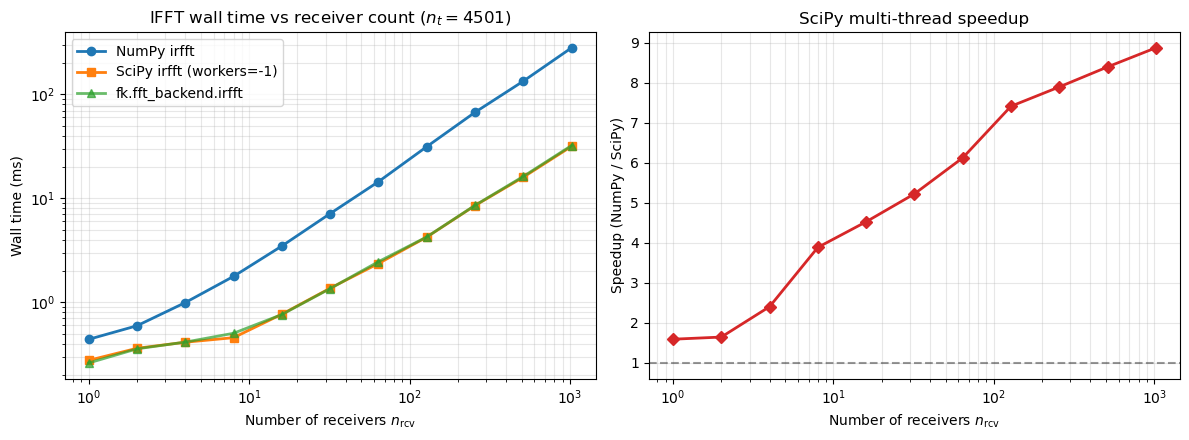

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(N_RCV_VALUES, times_numpy_rcv * 1e3, "o-", label="NumPy irfft", lw=2)
ax.loglog(N_RCV_VALUES, times_scipy_rcv * 1e3, "s-", label="SciPy irfft (workers=-1)", lw=2)
ax.loglog(N_RCV_VALUES, times_fk_rcv * 1e3, "^-", label="fk.fft_backend.irfft", lw=2, alpha=0.7)
ax.set_xlabel("Number of receivers $n_{\\mathrm{rcv}}$")
ax.set_ylabel("Wall time (ms)")
ax.set_title(f"IFFT wall time vs receiver count ($n_t={NT_DEFAULT}$)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax = axes[1]
ax.semilogx(N_RCV_VALUES, speedup_rcv, "D-", color="C3", lw=2)
ax.axhline(1.0, color="k", ls="--", alpha=0.4)
ax.set_xlabel("Number of receivers $n_{\\mathrm{rcv}}$")
ax.set_ylabel("Speedup (NumPy / SciPy)")
ax.set_title("SciPy multi-thread speedup")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Scaling with time samples `nt`

Fixed `nrcv = 64` receivers.  Time lengths cover typical FK and benchmark settings.

In [ ]:
N_RCV_FIXED = 64
NT_VALUES = [512, 1024, 2048, 4096, 4501, 8192, 16384]

times_numpy_nt = []
times_scipy_nt = []

for nt in NT_VALUES:
    spec = make_spec(N_RCV_FIXED, nt, rng)
    t_np, _ = bench_pair_irfft(numpy_irfft, spec, nt)
    t_sp, _ = bench_pair_irfft(scipy_irfft_mt, spec, nt)
    times_numpy_nt.append(t_np)
    times_scipy_nt.append(t_sp)
    print(f"nt={nt:5d}  numpy={t_np*1e3:7.2f} ms  scipy={t_sp*1e3:7.2f} ms  speedup={t_np/t_sp:5.2f}x")

times_numpy_nt = np.array(times_numpy_nt)
times_scipy_nt = np.array(times_scipy_nt)
speedup_nt = times_numpy_nt / times_scipy_nt

nt=  512  numpy=   0.19 ms  scipy=   0.19 ms  speedup= 1.02x


nt= 1024  numpy=   0.53 ms  scipy=   0.23 ms  speedup= 2.28x


nt= 2048  numpy=   0.96 ms  scipy=   0.51 ms  speedup= 1.88x


nt= 4096  numpy=   2.06 ms  scipy=   1.03 ms  speedup= 1.99x


nt= 4501  numpy=  15.82 ms  scipy=   2.72 ms  speedup= 5.82x


nt= 8192  numpy=   4.69 ms  scipy=   1.37 ms  speedup= 3.42x


nt=16384  numpy=  10.13 ms  scipy=   2.00 ms  speedup= 5.07x


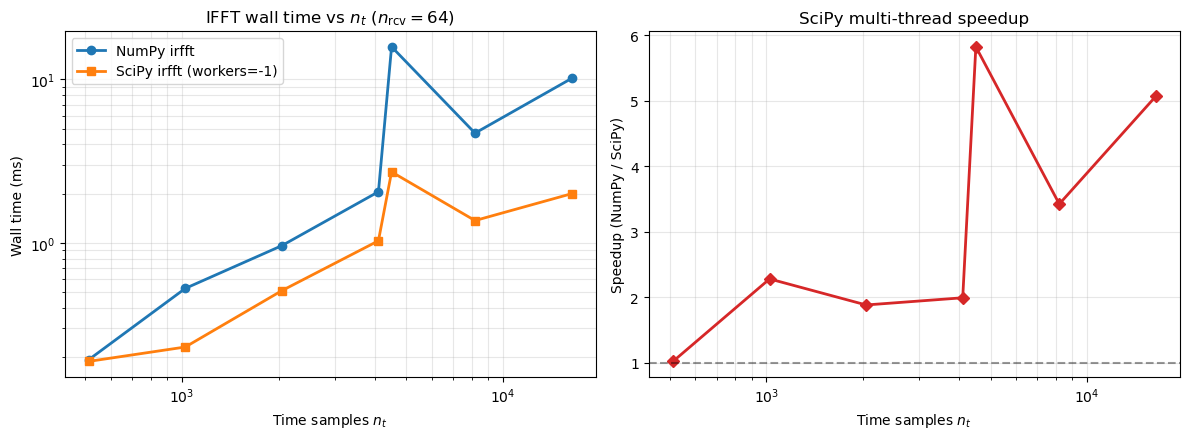

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.loglog(NT_VALUES, times_numpy_nt * 1e3, "o-", label="NumPy irfft", lw=2)
ax.loglog(NT_VALUES, times_scipy_nt * 1e3, "s-", label="SciPy irfft (workers=-1)", lw=2)
ax.set_xlabel("Time samples $n_t$")
ax.set_ylabel("Wall time (ms)")
ax.set_title(f"IFFT wall time vs $n_t$ ($n_{{\\mathrm{{rcv}}}}={N_RCV_FIXED}$)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax = axes[1]
ax.semilogx(NT_VALUES, speedup_nt, "D-", color="C3", lw=2)
ax.axhline(1.0, color="k", ls="--", alpha=0.4)
ax.set_xlabel("Time samples $n_t$")
ax.set_ylabel("Speedup (NumPy / SciPy)")
ax.set_title("SciPy multi-thread speedup")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Combined scaling heatmap

Speedup over a grid of `(nrcv, nt)` pairs.

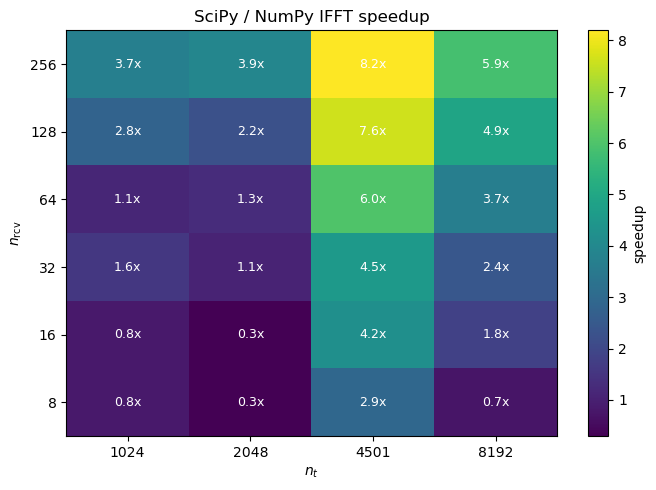

In [ ]:
N_RCV_GRID = [8, 16, 32, 64, 128, 256]
NT_GRID = [1024, 2048, 4501, 8192]

speedup_grid = np.zeros((len(N_RCV_GRID), len(NT_GRID)))

for i, nrcv in enumerate(N_RCV_GRID):
    for j, nt in enumerate(NT_GRID):
        spec = make_spec(nrcv, nt, rng)
        t_np, _ = bench_pair_irfft(numpy_irfft, spec, nt, n_warmup=1, n_runs=5)
        t_sp, _ = bench_pair_irfft(scipy_irfft_mt, spec, nt, n_warmup=1, n_runs=5)
        speedup_grid[i, j] = t_np / t_sp

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(speedup_grid, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(range(len(NT_GRID)))
ax.set_xticklabels(NT_GRID)
ax.set_yticks(range(len(N_RCV_GRID)))
ax.set_yticklabels(N_RCV_GRID)
ax.set_xlabel("$n_t$")
ax.set_ylabel("$n_{\\mathrm{rcv}}$")
ax.set_title("SciPy / NumPy IFFT speedup")
for i in range(len(N_RCV_GRID)):
    for j in range(len(NT_GRID)):
        ax.text(j, i, f"{speedup_grid[i, j]:.1f}x", ha="center", va="center", color="w", fontsize=9)
fig.colorbar(im, ax=ax, label="speedup")
plt.tight_layout()
plt.show()

## 6. Takeaways

- For **small** FK jobs (few receivers), both backends are sub-millisecond; SciPy
  gives a modest speedup.
- Speedup **grows with batch size** (`nrcv` and `nt`) because SciPy parallelises
  independent transforms along `axis=1`.
- The FK module now uses `fk.fft_backend`, which matches the SciPy path shown here.
- **FFT wall time depends on the factorisation of `nt`, not just its magnitude.**
  A smaller `nt` can be *slower* than a larger one: e.g. `nt = 4051` (prime) is
  much slower than `nt = 8192 = 2^{13}` because prime lengths force the FFT
  library onto slow code paths (Bluestein / direct DFT), while powers of two use
  highly optimised radix-2 butterflies.  The project default `nt = 4501 = 7 × 643`
  is also sub-optimal for the same reason.
- **Recommendation:** choose `nt` as a **power of two** whenever possible
  (e.g. 2048, 4096, 8192).  If the total record length is set by `T` and `dt`,
  round `nt = floor(T / dt) + 1` up to the nearest power of two and adjust `dt`
  slightly, or accept a small change in the time window.  Avoid prime or
  large-prime `nt` values unless required for numerical reasons.
- The dominant cost in full `compute_fk_seismograms` remains the **Numba propagator**
  step; see notebook `1.2_fk_speed.ipynb` for that comparison.